# LangGraph Componends

Notes: 
- Prompt templates allow reusable prompts
- Prompts can have user input built in
- More prompts can be found from the LangSmith hub: https://smith.langchain.com/hub/
- LangGraph helps to describe and orgestrate workflows and create cyclic graphs
- Built in persistance helps to remember previous conversations
- Persistance leads to human in the loop workflows
- Controlability within graphs are important and highlighted in LangGraph
- Agent State tracks the state of the agent at each node and edge that is local and stored in persistance so that any state can be restored later on

This code will show an easier way to create the code from L1

In [2]:
from dotenv import load_dotenv
_ = load_dotenv()

In [3]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI # langchain wrapper around the open ai API
# This exposes a standard interface for all language models 
# This agent uses OpenAI, but it can be switched to any language model providers that LangChain supports ...
# without chaning any other lines of code
from langchain_community.tools.tavily_search import TavilySearchResults # used as the tool in this example

/tmp/ipykernel_92568/591515742.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools.tavily_search import TavilySearchResults # used as the tool in this example


In [4]:
tool = TavilySearchResults(max_results=2) #number of responses from the search API
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


/tmp/ipykernel_92568/819488524.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=2) #number of responses from the search API


In [5]:
# an annotated list of messages that we will add to over time
class AgentState(TypedDict): 
    messages: Annotated[list[AnyMessage], operator.add]

Note: in take_action below, some logic was added to cover the case that the LLM returned a non-existent tool name. Even with function calling, LLMs can still occasionally hallucinate. Note that all that is done is instructing the LLM to try again! An advantage of an agentic organization.

In [6]:
class Agent:
    """
    This Agent has three functions:
    1. call_openai: calls the LLM with the current messages and returns the response
    2. exists_action: checks if there is an action present in the LLM response 
    3. take_action: takes the action and returns the result to the LLM
    """
    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges( # checks whether there is an action present and routes to the appropriate node
            "llm", # node where the edge starts
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm") # edge starts from action and ends at llm, so the result of the action is sent back to the LLM
        graph.set_entry_point("llm")
        self.graph = graph.compile() # langchain runnable
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools) # letting the model know what tools are available to it

    def exists_action(self, state: AgentState): 
        """
        Defining the conditional edge
        This function checks if the last message from the LLM contains a tool call.
        """
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState): # get the messages from the state, add the system message, call the model
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]} # Since the agent state uses operator.add, this will not overwrite the previous messages

    def take_action(self, state: AgentState):
        # Once this stage is reached, we know that the LLM has requested a tool call, so we can take a look at the end of the messages
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [7]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(model="gpt-3.5-turbo")  #reduce inference cost
abot = Agent(model, [tool], system=prompt)

In [ ]:
#import sys
#!{sys.executable} -m pip install pygraphviz

Defaulting to user installation because normal site-packages is not writeable


Fontconfig warning: "/usr/share/fontconfig/conf.avail/05-reset-dirs-sample.conf", line 6: unknown element "reset-dirs"


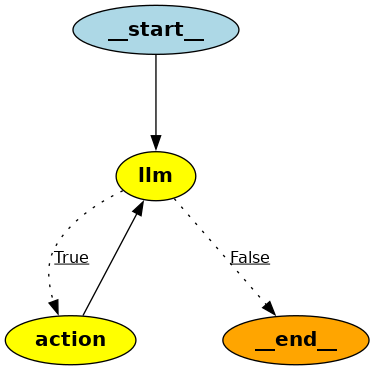

In [8]:
# Visualizing the graph 
from IPython.display import Image

Image(abot.graph.get_graph().draw_png())

In [9]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages}) # making the message conform to this state

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_JbCSlDrccQuFnJIFZLM833CP', 'type': 'tool_call'}
Back to the model!


In [ ]:
result # this shows the final state the agent ended up in

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 153, 'total_tokens': 174, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-DxI4NmzkayD4NMponZqWIPh1X1uu3', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f2476-a180-7292-9918-04016fcd8b27-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_JbCSlDrccQuFnJIFZLM833CP', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 153, 'output_tokens': 21, 'total_to

In [11]:
result['messages'][-1].content # getting the last message from the Agent State

'The weather in San Francisco is currently showing daily high temperatures ranging from 13°C to 27°C, with overnight lows between 14°C and 28°C. The average high for February is 16°C with an average low of 24°C. For more detailed information, you can visit [AccuWeather](https://www.accuweather.com/en/us/san-francisco/94103/february-weather/347629).'

In [12]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_WfpJNndlJtDcqWXAZ4dvfn3p', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in Los Angeles'}, 'id': 'call_EJNSkXdFKOIfhKwHV0zqnyWh', 'type': 'tool_call'}
Back to the model!


The fact that the Agent does not come back to the model before using the second tool call is an example of **paralell** function/tool calling.

In [14]:
result['messages'][-1].content # getting the last message from the Agent State

'The weather in San Francisco shows daily high temperatures ranging from 13°C to 27°C with overnight lows between 14°C and 28°C. The average high for February is around 16°C with an average low of about 24°C. In Los Angeles, the weather data for February 2026 indicates temperatures ranging from a high of 68°F to a low of 61°F with varying conditions like haze, mist, heavy rain, light rain, and fog throughout the month.'

In [15]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.

query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatOpenAI(model="gpt-4o")  # requires more advanced model
abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': '2024 Super Bowl winner'}, 'id': 'call_k1U6tjIAwtyNHMid4k9DYjn1', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas City Chiefs headquarters location'}, 'id': 'call_o5qAcBDn92tK1DxS1HrLSFsO', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Missouri GDP 2024'}, 'id': 'call_eZ0yRu57O6CvIUkqWbcbyuJa', 'type': 'tool_call'}
Back to the model!


In [16]:
print(result['messages'][-1].content) 

1. **Who won the Super Bowl in 2024?**  
   The Kansas City Chiefs won the Super Bowl in 2024, defeating the San Francisco 49ers.

2. **In what state is the winning team's headquarters located?**  
   The headquarters of the Kansas City Chiefs is located in Missouri.

3. **What is the GDP of that state?**  
   In 2024, the real gross domestic product (GDP) of Missouri was approximately $356.65 billion.


This is not parallel calling because it needs the results of the first query for the next search.